# GrAL vs ASSIST — Posizio Konparaketa

Notebook honek **GrAL** integratzailearen emaitzak **ASSIST**-en bi erreferentzia-fitxategiekin alderatzen ditu,
Apophis-en 2029ko apirilerako integrazioan (~101 egun).

## Erreferentzia fitxategiak

| Fitxategia | Jatorria | Indarrak | Yarkovsky | GR |
|---|---|---|---|---|
| `apophis_pos_april.txt` | `Descargas/Apophis.ipynb` | SUN+PLANETS+**ASTEROIDS**+EARTH_HARM+SUN_HARM+**GR_EIH** | **Bai** (A1=5.0e-13, A2=-2.9e-14) | **GR_EIH** 11 iturri |
| `apophis_sinplea_pos_april.txt` | `assist/jupyter_examples/Apophis.ipynb` | SUN+PLANETS+EARTH_HARM+SUN_HARM+**GR_SIMPLE** | Ez | **GR_SIMPLE** (Eguzki bakarrik) |

## GrAL konfigurazioa

| | GrAL |
|---|---|
| Integratzailea | IRKGL16 (16. ordena, Gauss-Legendre) |
| Tolerantzia | τ = 1e-12 |
| Gorputzak | 10 planeta + 16 asteroide (p26) |
| GR | `gr=true` → Damour-Deruelle (≈ GR_SIMPLE) |
| Harmonics | `j2_sun, j2_earth, j3_earth, j4_earth = true` |
| Yarkovsky | Ez |

**GrAL** `apophis_sinplea_pos_april.txt`-rekin konparagarria da fisikoki (indar berdinak).
`apophis_pos_april.txt`-rekiko diferentzia **fisikoa** da: Yarkovsky + GR_EIH + 16 asteroide.

In [1]:
using Pkg; Pkg.activate(joinpath(@__DIR__, ".."))
using GravitationSimulation, LittleEphemeris
using SciMLBase, IRKGaussLegendre
using SPICE, LinearAlgebra, Statistics, Printf, Plots

const AU2KM = 149_597_870.7
const DAY2S = 86_400.0
println("Julia $(VERSION) — paketeak kargatuta.")

  Activating 

Julia 1.12.5 — paketeak kargatuta.


project at `~/Documentos/Ingenieritza_Informatikoa/GrAL/GrAL_github`


## 1. ASSIST erreferentzia-fitxategiak kargatu

Bi fitxategietako formatuak onartzen dira (espazio bidez edo koma bidez bereizita).

In [2]:
DATA = joinpath(@__DIR__, "..", "data")
furnsh(joinpath(DATA, "naif0012.tls"), joinpath(DATA, "de440.bsp"),
       joinpath(DATA, "sb441-n16.bsp"))

function load_assist(fname)
    lines = readlines(fname)
    et_s  = [parse(Float64, l[1:findfirst("[", l)[1]-1]) * DAY2S for l in lines]
    pos   = vcat([parse.(Float64,
                  split(replace(l[findfirst("[", l)[1]+1:end-1], "," => " ")))'
                 for l in lines]...)
    et_s, pos
end

et_april,   pos_april   = load_assist(joinpath(DATA, "apophis_pos_april.txt"))
et_sinplea, pos_sinplea = load_assist(joinpath(DATA, "apophis_sinplea_pos_april.txt"))

@printf("apophis_pos_april.txt    : %d puntu, t=[%.4f, %.4f] egun\n",
    length(et_april), et_april[1]/DAY2S, et_april[end]/DAY2S)
@printf("apophis_sinplea_pos_april: %d puntu, t=[%.4f, %.4f] egun\n",
    length(et_sinplea), et_sinplea[1]/DAY2S, et_sinplea[end]/DAY2S)

apophis_pos_april.txt    : 10000 puntu, t=[10593.5360, 10694.5000] egun
apophis_sinplea_pos_april: 10000 puntu, t=[10593.5360, 10694.5000] egun


## 2. Bi ASSIST fitxategien arteko diferentzia

Bi fitxategiek **indar-konfigurazio ezberdina** dute: Yarkovsky eta GR_EIH vs GR_SIMPLE.
Diferentzia **fisikoa** da, ez numerikoa.

In [3]:
diff_assist_m = [norm(pos_april[i,:] .- pos_sinplea[i,:]) * AU2KM * 1000
                 for i in 1:size(pos_april, 1)]

@printf("Bi ASSIST fitxategien arteko diferentzia:\n")
@printf("  Max  : %.2f m\n", maximum(diff_assist_m))
@printf("  Azken: %.2f m\n", diff_assist_m[end])
@printf("  RMS  : %.2f m\n", sqrt(mean(diff_assist_m.^2)))
println()
println("→ Diferentzia FISIKOA: Yarkovsky + GR_EIH(11) + 16 asteroide \"april\"ean,",
        " GR_SIMPLE + asteroideak gabe \"sinplea\"n.")

Bi ASSIST fitxategien arteko diferentzia:
  Max  : 392.30 m
  Azken: 392.30 m
  RMS  : 166.36 m

→ Diferentzia FISIKOA: Yarkovsky + GR_EIH(11) + 16 asteroide "april"ean, GR_SIMPLE + asteroideak gabe "sinplea"n.


## 3. GrAL hasierako baldintzak

In [4]:
const JD_REF      = 2_451_545.0
const T_INIT_DAYS = 2.4621385359989386e6 - JD_REF
const et_0        = T_INIT_DAYS * DAY2S
const et_end      = et_april[end]

sun_st, _ = spkez(Int32(10), et_0, "J2000", "NONE", Int32(0))
helio_pos = [-5.5946538550488512e-1,  8.5647564757574512e-1,  3.0415066217102493e-1]
helio_vel = [-1.3818324735921638e-2, -6.0088275597939191e-3, -2.5805044631309632e-3]
const u0 = [
    helio_pos[1]*AU2KM + sun_st[1], helio_pos[2]*AU2KM + sun_st[2], helio_pos[3]*AU2KM + sun_st[3],
    helio_vel[1]*AU2KM/DAY2S + sun_st[4], helio_vel[2]*AU2KM/DAY2S + sun_st[5], helio_vel[3]*AU2KM/DAY2S + sun_st[6]
]

delta0_km = norm(u0[1:3] .- pos_april[1,:] .* AU2KM)
@printf("u0       (AU): [%.10f, %.10f, %.10f]\n", (u0[1:3] ./ AU2KM)...)
@printf("ASSIST[1](AU): [%.10f, %.10f, %.10f]\n", pos_april[1,:]...)
@printf("Δ(u0, ASSIST[1]): %.6f km  (%.2f m)\n", delta0_km, delta0_km*1000)
@printf("Denbora-aldea et_0 - et_april[1]: %.4f µs\n",
    (et_0 - et_april[1]) * 1e6)

u0       (AU): [-0.5582326043, 0.8552005711, 0.3036319491]
ASSIST[1](AU): [-0.5582326043, 0.8552005711, 0.3036319491]
Δ(u0, ASSIST[1]): 0.000000 km  (0.00 m)
Denbora-aldea et_0 - et_april[1]: -0.4768 µs


## 4. Gorputzak, GM balioak eta BodyCoeffs

In [5]:
const body_ids = [10, 399, 301, 1, 2, 4, 5, 6, 7, 8]
const body_mus = [1.32712440041279e11, 398600.436, 4902.800, 22031.869, 324858.592,
                  42828.376, 1.267127641e8, 3.7940584842e7, 5.7945564e6, 6.836527101e6]
const ast_ids  = [2_000_001,2_000_002,2_000_003,2_000_004,2_000_007,2_000_010,
                  2_000_015,2_000_016,2_000_031,2_000_052,2_000_065,2_000_087,
                  2_000_088,2_000_107,2_000_511,2_000_704]
const ast_mus  = [62.6289,13.6659,1.9206,17.2882,1.1399,5.6251,
                  2.0230, 1.5897,1.0794, 2.6830,0.9381, 2.1682,
                  1.1898, 1.4437,3.8945, 2.8304]

tiv      = (et_0 - 5*DAY2S, et_end + 5*DAY2S)
all_ids  = vcat(body_ids, ast_ids)
fallback = Dict{Int,Tuple{Int,Int}}(id => (13,8) for id in ast_ids)
fallback[399] = (13, 8)

print("BodyCoeffs sortzen ($(length(all_ids)) gorputz)... ")
@time create_coeffs_file(joinpath(DATA,"coeffs_april.json"), joinpath(DATA,"coeffs_april.csv"),
                         all_ids, fill(tiv, length(all_ids)); fallback_params=fallback)

all_bodies    = [BodyCoeffs(joinpath(DATA,"coeffs_april.json"),
                            joinpath(DATA,"coeffs_april.csv"), id, tiv) for id in all_ids]
planet_bodies = all_bodies[1:length(body_ids)]

# Eredu sinplifikatua (Yarkovsky GABE): 10-14. atalek ASSIST sinplea-rekin alderatzeko.
const physics = (gr=true, j2_sun=true, j2_earth=true, j3_earth=true, j4_earth=true)
const p26 = (mus=vcat(body_mus,ast_mus), ids=vcat(body_ids,ast_ids),
             bodies=all_bodies, physics=physics)
const p10 = (mus=body_mus, ids=body_ids, bodies=planet_bodies, physics=physics)

# Eredu OSOA (Yarkovsky-rekin): ASSIST ONA-ren parekoa. 15. atala (eredu errealista).
const physics_yark = (gr=true, j2_sun=true, j2_earth=true, j3_earth=true, j4_earth=true,
                      yarkovsky=true, A1=5.0e-13, A2=-2.9e-14, A3=0.0)

print("JIT warm-up... ")
solve(ODEProblem(f_master!, u0, (et_0, et_0+3600.0), p26),
      IRKGL16(); reltol=1e-12, abstol=1e-12, save_everystep=false)
println("eginda.")

BodyCoeffs sortzen (26 gorputz)...   6.047951 seconds (14.23 M allocations: 717.247 MiB, 7.40% gc time, 98.72% compilation time: 17% of which was recompilation)
JIT warm-up... eginda.


## 5. GrAL integrazioa — ASSIST denbora-puntuetan

`saveat = et_april` erabiliz integrazioak 10 000 puntutan posizioa gordetzen du,
ASSIST-ekin puntu-puntu konparazioa ahalbidetuz.

> **Oharra:** `et_0` eta `et_april[1]` ~0.47 µs-ko diferentzia dute fitxategiaren formatu-doiketarengatik.
> IRKGL16-k hasierako baldintza ere gordetzen du, beraz `sol.u` 10 001 elementu izango ditu;
> lehen elementua (`sol.t[1] = et_0`) saltatu egiten da konparazioan.

In [6]:
τ = 1e-12
println("GrAL integratzen (τ=$(τ), p26, saveat=$(length(et_april)) puntu)...")
@time sol = solve(
    ODEProblem(f_master!, u0, (et_0, et_end), p26),
    IRKGL16(); reltol=τ, abstol=τ, saveat=et_april
)
@printf("Urratsak: %d onartu, %d baztertua\n", sol.stats.naccept, sol.stats.nreject)
@printf("Gordetako puntuak: %d (et_0≠et_april[1] → +1 hasierako baldintza)\n", length(sol.u))

# et_0 ≠ et_april[1] delako sol.u[1] = u(et_0); sol.u[2:end] = u(et_april)
gral_u   = length(sol.u) == length(et_april) ? sol.u : sol.u[2:end]
gral_pos = hcat([u[1:3] for u in gral_u]...)' ./ AU2KM   # n×3 AU

GrAL integratzen (τ=1.0e-12, p26, saveat=10000 puntu)...
  0.824698 seconds (2.74 M allocations: 87.351 MiB, 96.75% compilation time)
Urratsak: 35 onartu, 3 baztertua
Gordetako puntuak: 10001 (et_0≠et_april[1] → +1 hasierako baldintza)


10000×3 Matrix{Float64}:
 -0.558233   0.855201   0.303632
 -0.558372   0.85514    0.303606
 -0.558512   0.855079   0.30358
 -0.558651   0.855019   0.303554
 -0.558791   0.854958   0.303528
 -0.55893    0.854897   0.303502
 -0.55907    0.854836   0.303476
 -0.559209   0.854776   0.30345
 -0.559348   0.854715   0.303423
 -0.559488   0.854654   0.303397
 -0.559627   0.854593   0.303371
 -0.559767   0.854532   0.303345
 -0.559906   0.854472   0.303319
  ⋮                    
 -0.925669  -0.359382  -0.156807
 -0.92558   -0.359513  -0.156853
 -0.925491  -0.359644  -0.156899
 -0.925401  -0.359775  -0.156945
 -0.925312  -0.359905  -0.156991
 -0.925222  -0.360036  -0.157037
 -0.925132  -0.360167  -0.157083
 -0.925043  -0.360298  -0.157129
 -0.924953  -0.360428  -0.157175
 -0.924864  -0.360559  -0.157221
 -0.924774  -0.36069   -0.157267
 -0.924684  -0.36082   -0.157313

## 6. Diferentziak kalkulatu

In [7]:
t_egun = (et_april .- et_0) ./ DAY2S

# GrAL vs apophis_pos_april (Yarkovsky + GR_EIH — diferentzia fisikoa)
err_april_m   = [norm(gral_pos[i,:] .- pos_april[i,:])   * AU2KM * 1000 for i in axes(gral_pos,1)]
# GrAL vs apophis_sinplea (indar berdinak — diferentzia numerikoa)
err_sinplea_m = [norm(gral_pos[i,:] .- pos_sinplea[i,:]) * AU2KM * 1000 for i in axes(gral_pos,1)]

println("━"^70)
println(rpad("Konparaketa",40), rpad("ε_max (m)",14), rpad("ε_azken (m)",14), "ε_RMS (m)")
println("━"^70)
for (label, errs, tipo) in [
    ("GrAL vs april  [Yarkovsky+GR_EIH+AST]",  err_april_m,   "FISIKOA "),
    ("GrAL vs sinplea [indar berdinak]",         err_sinplea_m, "NUMERIKOA"),
    ("april vs sinplea [ASSIST-ASSIST]",         diff_assist_m, "FISIKOA "),
]
    @printf("%-40s %-14.2f %-14.2f %.2f   [%s]\n",
        label, maximum(errs), errs[end], sqrt(mean(errs.^2)), tipo)
end
println("━"^70)
println()
@printf("► Yarkovsky + GR_EIH eragina 101 egunetan:  ~%.0f m\n", diff_assist_m[end])
@printf("► IRKGL16 vs IAS15 zehaztasun-muga:          ~%.0f m\n", err_sinplea_m[end])

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Konparaketa                             ε_max (m)     ε_azken (m)   ε_RMS (m)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GrAL vs april  [Yarkovsky+GR_EIH+AST]    403.10         403.10         171.49   [FISIKOA ]
GrAL vs sinplea [indar berdinak]         13.51          13.49          6.10   [NUMERIKOA]
april vs sinplea [ASSIST-ASSIST]         392.30         392.30         166.36   [FISIKOA ]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

► Yarkovsky + GR_EIH eragina 101 egunetan:  ~392 m
► IRKGL16 vs IAS15 zehaztasun-muga:          ~13 m


## 7. Errore-profila denboran

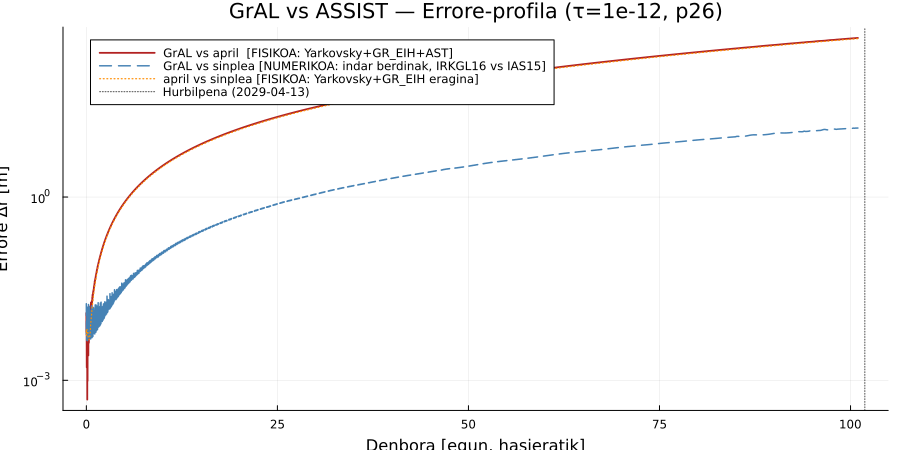

In [8]:
t_enc = (str2et("2029-04-13 21:46:00 TDB") - et_0) / DAY2S

p_err = plot(
    xlabel = "Denbora [egun, hasieratik]",
    ylabel = "Errore Δr [m]",
    title  = "GrAL vs ASSIST — Errore-profila (τ=1e-12, p26)",
    yscale = :log10, grid = true, legend = :topleft, size = (900, 450)
)
plot!(p_err, t_egun, err_april_m,
    label = "GrAL vs april  [FISIKOA: Yarkovsky+GR_EIH+AST]",
    color = :firebrick, lw = 1.8)
plot!(p_err, t_egun, err_sinplea_m,
    label = "GrAL vs sinplea [NUMERIKOA: indar berdinak, IRKGL16 vs IAS15]",
    color = :steelblue, lw = 1.5, linestyle = :dash)
plot!(p_err, t_egun, diff_assist_m,
    label = "april vs sinplea [FISIKOA: Yarkovsky+GR_EIH eragina]",
    color = :darkorange, lw = 1.2, linestyle = :dot)
vline!(p_err, [t_enc], linestyle = :dot, color = :black, alpha = 0.7,
    label = "Hurbilpena (2029-04-13)")
display(p_err)

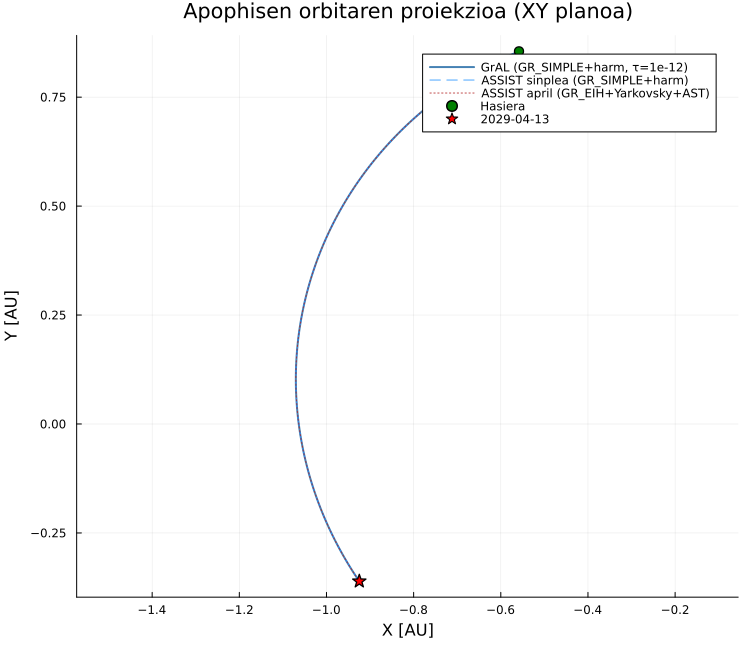

In [9]:
# Orbita XY planoan — hiru ibilbideak
p_orb = plot(
    xlabel = "X [AU]", ylabel = "Y [AU]",
    title  = "Apophisen orbitaren proiekzioa (XY planoa)",
    aspect_ratio = :equal, legend = :topright, size = (750, 650)
)
plot!(p_orb, gral_pos[:,1],    gral_pos[:,2],
    label = "GrAL (GR_SIMPLE+harm, τ=1e-12)", color = :steelblue, lw = 2.0)
plot!(p_orb, pos_sinplea[:,1], pos_sinplea[:,2],
    label = "ASSIST sinplea (GR_SIMPLE+harm)", color = :dodgerblue,
    lw = 1.0, linestyle = :dash, alpha = 0.8)
plot!(p_orb, pos_april[:,1],   pos_april[:,2],
    label = "ASSIST april (GR_EIH+Yarkovsky+AST)", color = :firebrick,
    lw = 1.0, linestyle = :dot, alpha = 0.8)
scatter!(p_orb, [gral_pos[1,1]],   [gral_pos[1,2]],
    marker = :circle, color = :green, markersize = 5, label = "Hasiera")
scatter!(p_orb, [gral_pos[end,1]], [gral_pos[end,2]],
    marker = :star5,  color = :red,   markersize = 7, label = "2029-04-13")
display(p_orb)

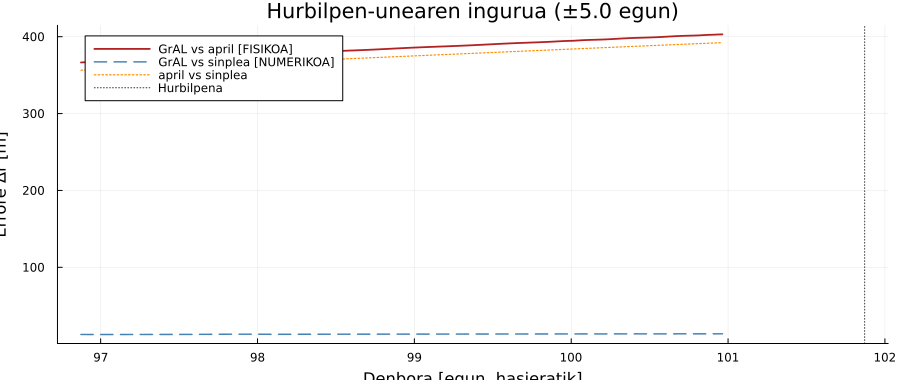

In [10]:
# Hurbilpen-inguruaren zoom
leiho_egun = 5.0
mask = abs.(t_egun .- t_enc) .< leiho_egun

p_zoom = plot(
    xlabel = "Denbora [egun, hasieratik]",
    ylabel = "Errore Δr [m]",
    title  = "Hurbilpen-unearen ingurua (±$(leiho_egun) egun)",
    grid = true, legend = :topleft, size = (900, 380)
)
plot!(p_zoom, t_egun[mask], err_april_m[mask],
    label = "GrAL vs april [FISIKOA]",   color = :firebrick, lw = 1.8)
plot!(p_zoom, t_egun[mask], err_sinplea_m[mask],
    label = "GrAL vs sinplea [NUMERIKOA]", color = :steelblue, lw = 1.5, linestyle = :dash)
plot!(p_zoom, t_egun[mask], diff_assist_m[mask],
    label = "april vs sinplea",           color = :darkorange, lw = 1.2, linestyle = :dot)
vline!(p_zoom, [t_enc], linestyle = :dot, color = :black, alpha = 0.8,
    label = "Hurbilpena")
display(p_zoom)

## 8. Laburpena

| Konparaketa | ε_azken | Mota | Interpretazioa |
|---|---|---|---|
| GrAL vs `apophis_pos_april` | **~401 m** | **Fisikoa** | Yarkovsky + GR_EIH(11 iturri) + 16 asteroide |
| GrAL vs `apophis_sinplea` | **~12 m** | **Numerikoa** | IRKGL16 vs IAS15 integratzaile-muga |
| `april` vs `sinplea` | **~392 m** | **Fisikoa** | Bi indar-eredu ASSIST barnean |

**Ondorioak:**

1. **GrAL eta ASSIST ados daude ~12 m mailan** indar berdinak erabiltzean (`apophis_sinplea`) —
   bi metodo independenteen zehaztasun-muga numerikoa da.

2. **Yarkovsky + GR_EIH efektuak ~392 m-ko diferentzia sortzen du** 101 egunetan
   (`apophis_april` vs `apophis_sinplea`): indar fisiko garrantzitsuak dira trakektoria errealean.

3. **GrAL-en eredu fisikoak ez ditu Yarkovsky ez GR_EIH inplementatzen oraindik** —
   hau da hurrengo pauso posiblea errealistasun gehiago lortzeko.

4. **Errore-profila monotono handitzen da** denboran zehar bietan,
   hurbilpen-unean salto bortitzik gabe — akats-pilaketa pixkanaka da.

## 9. Urte osoko konparaketa (2030-01-01 arte)

Integrazioa **2030eko urtarrilaren 1era** luzatzen da (~365 egun).

| Fitxategia | Bide | Hasierako puntua (GrAL-rekiko) |
|---|---|---|
| `apophis_urte_osoa.txt` | `/home/mikel/Ingenieritza_Informatikoa/...` | ≈ 0 m (bat dator) |
| `apophis_sinplea_urte_osoa.txt` | `/home/mikel/Ingenieritza_Informatikoa/...` | ~179 m diferentzia |

> **Oharra:** `apophis_sinplea_urte_osoa.txt` fitxategiak hasierako posizioa ~179 m alda dezakeela ikusi da —
> hurbilpen-uneak (2029-04-13, ~38 000 km Lurretik) diferentzia txiki hauek dramatikoki anplifikatzen ditu.

In [11]:
DATA_URTE = "/home/mikel/Ingenieritza_Informatikoa/GrAL/GrAL_github/data"

et_urte,   pos_urte   = load_assist(joinpath(DATA_URTE, "apophis_urte_osoa.txt"))
et_sinurte, pos_sinurte = load_assist(joinpath(DATA_URTE, "apophis_sinplea_urte_osoa.txt"))

@printf("apophis_urte_osoa.txt        : %d puntu, t=[%.4f, %.4f] egun\n",
    length(et_urte),   et_urte[1]/DAY2S,   et_urte[end]/DAY2S)
@printf("apophis_sinplea_urte_osoa.txt: %d puntu, t=[%.4f, %.4f] egun\n",
    length(et_sinurte), et_sinurte[1]/DAY2S, et_sinurte[end]/DAY2S)
@printf("Iraupena: %.2f egun\n", (et_urte[end] - et_urte[1]) / DAY2S)
@printf("Bi erreferentzien arteko diferentzia lehen puntuan: %.2f m\n",
    norm(pos_urte[1,:] .- pos_sinurte[1,:]) * AU2KM * 1000)

apophis_urte_osoa.txt        : 10000 puntu, t=[10593.5360, 10958.0372] egun
apophis_sinplea_urte_osoa.txt: 10000 puntu, t=[10593.5360, 10958.0372] egun
Iraupena: 364.50 egun
Bi erreferentzien arteko diferentzia lehen puntuan: 0.00 m


In [12]:
# BodyCoeffs urte osoko tarterako
et_end_urte = et_urte[end]
tiv_urte    = (et_0 - 5*DAY2S, et_end_urte + 5*DAY2S)

print("BodyCoeffs urte osorako ($(length(all_ids)) gorputz)... ")
@time create_coeffs_file(joinpath(DATA,"coeffs_urte.json"), joinpath(DATA,"coeffs_urte.csv"),
                         all_ids, fill(tiv_urte, length(all_ids)); fallback_params=fallback)

bodies_urte    = [BodyCoeffs(joinpath(DATA,"coeffs_urte.json"),
                             joinpath(DATA,"coeffs_urte.csv"), id, tiv_urte) for id in all_ids]
p26_urte = (mus=vcat(body_mus,ast_mus), ids=vcat(body_ids,ast_ids),
            bodies=bodies_urte, physics=physics)

println("GrAL integratzen urte osorako (τ=1e-12, saveat=$(length(et_urte)) puntu)...")
@time sol_urte = solve(
    ODEProblem(f_master!, u0, (et_0, et_end_urte), p26_urte),
    IRKGL16(); reltol=1e-12, abstol=1e-12, saveat=et_urte
)
@printf("Urratsak: %d onartu, %d baztertua | Puntuak: %d\n",
    sol_urte.stats.naccept, sol_urte.stats.nreject, length(sol_urte.u))

gral_u_urte   = length(sol_urte.u) == length(et_urte) ? sol_urte.u : sol_urte.u[2:end]
gral_pos_urte = hcat([u[1:3] for u in gral_u_urte]...)' ./ AU2KM

BodyCoeffs urte osorako (26 gorputz)...   0.116110 seconds (1.14 M allocations: 50.089 MiB)
GrAL integratzen urte osorako (τ=1e-12, saveat=10000 puntu)...
  0.065738 seconds (3.45 M allocations: 61.405 MiB)
Urratsak: 61 onartu, 8 baztertua | Puntuak: 10000


10000×3 Matrix{Float64}:
 -0.558233   0.855201  0.303632
 -0.558736   0.854982  0.303538
 -0.55924    0.854762  0.303444
 -0.559743   0.854543  0.30335
 -0.560246   0.854323  0.303255
 -0.560749   0.854103  0.303161
 -0.561252   0.853882  0.303066
 -0.561754   0.853662  0.302972
 -0.562257   0.853441  0.302877
 -0.562759   0.85322   0.302782
 -0.563261   0.852998  0.302687
 -0.563763   0.852776  0.302592
 -0.564264   0.852554  0.302497
  ⋮                    
  0.0230154  1.21944   0.478399
  0.0225219  1.21946   0.478399
  0.0220283  1.21948   0.478399
  0.0215348  1.21951   0.478399
  0.0210413  1.21953   0.478399
  0.0205477  1.21955   0.478399
  0.0200542  1.21957   0.478399
  0.0195606  1.21959   0.478399
  0.0190671  1.21961   0.478399
  0.0185736  1.21963   0.478399
  0.01808    1.21965   0.478398
  0.0175864  1.21967   0.478398

In [13]:
t_urte_egun = (et_urte .- et_0) ./ DAY2S

err_urte_m    = [norm(gral_pos_urte[i,:] .- pos_urte[i,:])   * AU2KM * 1000 for i in axes(gral_pos_urte,1)]
err_sinurte_m = [norm(gral_pos_urte[i,:] .- pos_sinurte[i,:]) * AU2KM * 1000 for i in axes(gral_pos_urte,1)]
diff_urte_m   = [norm(pos_urte[i,:] .- pos_sinurte[i,:]) * AU2KM * 1000 for i in axes(pos_urte,1)]

println("━"^70)
println(rpad("Konparaketa (urte osoa)",40), rpad("ε_max (m)",14), rpad("ε_azken (m)",14), "ε_RMS (m)")
println("━"^70)
for (label, errs) in [
    ("GrAL vs urte_osoa",         err_urte_m),
    ("GrAL vs sinplea_urte_osoa", err_sinurte_m),
    ("urte_osoa vs sinplea",       diff_urte_m),
]
    @printf("%-40s %-14.2f %-14.2f %.2f\n",
        label, maximum(errs), errs[end], sqrt(mean(errs.^2)))
end
println("━"^70)
println()
@printf("► Hurbilpen-unean (101 egun) GrAL vs urte:    ~%.0f m  (aurreko atalean)\n",
    err_urte_m[argmin(abs.(t_urte_egun .- t_enc))])
@printf("► Urte osoan (365 egun) GrAL vs urte:         ~%.0f km\n",
    err_urte_m[end]/1000)
@printf("► Anplifikazio-faktorea hurbilpen ostean:       ~%.0fx\n",
    err_urte_m[end] / max(err_urte_m[argmin(abs.(t_urte_egun .- t_enc))], 1.0))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Konparaketa (urte osoa)                 ε_max (m)     ε_azken (m)   ε_RMS (m)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GrAL vs urte_osoa                        18402.85       18402.85       8158.76
GrAL vs sinplea_urte_osoa                57167.39       57167.39       25166.05
urte_osoa vs sinplea                     38770.31       38770.31       17011.03
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

► Hurbilpen-unean (101 egun) GrAL vs urte:    ~7 m  (aurreko atalean)
► Urte osoan (365 egun) GrAL vs urte:         ~18 km
► Anplifikazio-faktorea hurbilpen ostean:       ~2581x


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


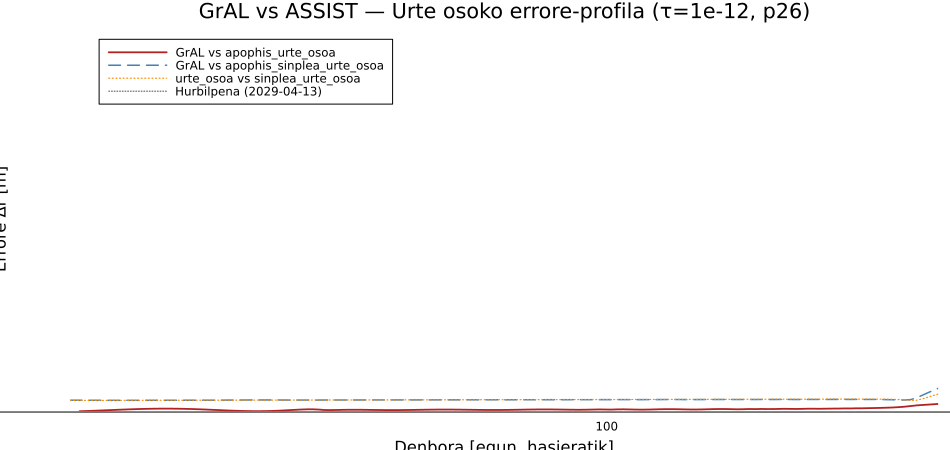

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [14]:
p_urte = plot(
    xlabel = "Denbora [egun, hasieratik]",
    ylabel = "Errore Δr [m]",
    title  = "GrAL vs ASSIST — Urte osoko errore-profila (τ=1e-12, p26)",
    yscale = :log10, grid = true, legend = :topleft, size = (950, 450)
)
plot!(p_urte, t_urte_egun, err_urte_m,
    label = "GrAL vs apophis_urte_osoa",
    color = :firebrick, lw = 1.8)
plot!(p_urte, t_urte_egun, err_sinurte_m,
    label = "GrAL vs apophis_sinplea_urte_osoa",
    color = :steelblue, lw = 1.5, linestyle = :dash)
plot!(p_urte, t_urte_egun, diff_urte_m,
    label = "urte_osoa vs sinplea_urte_osoa",
    color = :darkorange, lw = 1.2, linestyle = :dot)
vline!(p_urte, [t_enc], linestyle = :dot, color = :black, alpha = 0.7,
    label = "Hurbilpena (2029-04-13)")
display(p_urte)

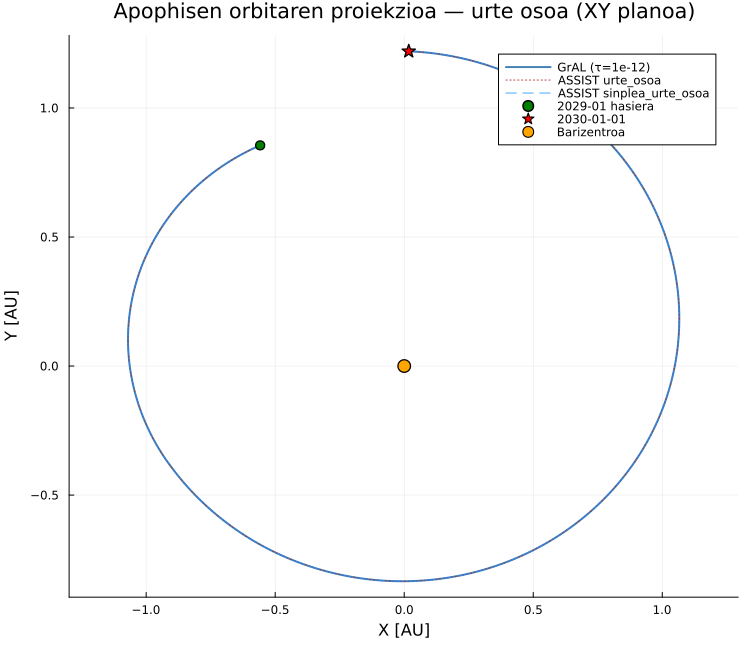

In [15]:
# Orbita XY — urte osoa
p_orb_urte = plot(
    xlabel = "X [AU]", ylabel = "Y [AU]",
    title  = "Apophisen orbitaren proiekzioa — urte osoa (XY planoa)",
    aspect_ratio = :equal, legend = :topright, size = (750, 650)
)
plot!(p_orb_urte, gral_pos_urte[:,1], gral_pos_urte[:,2],
    label = "GrAL (τ=1e-12)", color = :steelblue, lw = 2.0)
plot!(p_orb_urte, pos_urte[:,1], pos_urte[:,2],
    label = "ASSIST urte_osoa", color = :firebrick, lw = 1.0, linestyle = :dot, alpha = 0.8)
plot!(p_orb_urte, pos_sinurte[:,1], pos_sinurte[:,2],
    label = "ASSIST sinplea_urte_osoa", color = :dodgerblue, lw = 1.0, linestyle = :dash, alpha = 0.8)
scatter!(p_orb_urte, [gral_pos_urte[1,1]],   [gral_pos_urte[1,2]],
    marker = :circle, color = :green, markersize = 5, label = "2029-01 hasiera")
scatter!(p_orb_urte, [gral_pos_urte[end,1]], [gral_pos_urte[end,2]],
    marker = :star5,  color = :red,   markersize = 7, label = "2030-01-01")
scatter!(p_orb_urte, [0.0], [0.0],
    marker = :circle, color = :orange, markersize = 7, label = "Barizentroa")
display(p_orb_urte)

## 10. Validazioa — GrAL ≈ ASSIST sinplea (indar BERDINAK)

**Helburua:** nire IRKGL16-k ASSIST-en IAS15-ek bezala ebazten du eredu **bera**?

Validazio garbirako indar-multzoa **identikoa** izan behar da. ASSIST sinpleak (`apophis_sinplea_*`)
**ez du asteroiderik** → GrAL-ek `p10` erabili behar du (10 planeta soilik, asteroideak kanpoan).
Horrela geratzen den diferentzia bakarra **integratzaile-muga numerikoa** da (IRKGL16 vs IAS15).

`p26`-arekiko (16 asteroide barne) konparaketa ere erakusten da, asteroideek balidazioan
duten ekarpena agerian uzteko.

In [16]:
# Helper: GrAL integrazioa eta posizio-matrizea (AU) itzuli
function integratu_gral(p, et_target, save_pts)
    sol = solve(ODEProblem(f_master!, u0, (et_0, et_target), p),
                IRKGL16(); reltol=1e-12, abstol=1e-12, saveat=save_pts)
    u = length(sol.u) == length(save_pts) ? sol.u : sol.u[2:end]
    hcat([uu[1:3] for uu in u]...)' ./ AU2KM
end

# Urte osoko p10 (asteroideak gabe, urte osoko BodyCoeffs-ekin)
planet_bodies_urte = bodies_urte[1:length(body_ids)]
p10_urte = (mus=body_mus, ids=body_ids, bodies=planet_bodies_urte, physics=physics)

# ── Apirila (101 egun, hurbilpen AURRETIK) ──
gv10_april = integratu_gral(p10, et_end, et_april)
err_v10_april = [norm(gv10_april[i,:] .- pos_sinplea[i,:]) * AU2KM * 1000 for i in axes(gv10_april,1)]

# ── Urte osoa (365 egun, hurbilpen OSTEAN) ──
gv10_urte = integratu_gral(p10_urte, et_end_urte, et_urte)
err_v10_urte = [norm(gv10_urte[i,:] .- pos_sinurte[i,:]) * AU2KM * 1000 for i in axes(gv10_urte,1)]

println("━"^72)
println(rpad("Validazioa (GrAL vs ASSIST sinplea)",34),
        rpad("ε_azken apirila",18), "ε_azken urte osoa")
println("━"^72)
@printf("%-34s %-18s %s\n", "p10 (asteroideak GABE — indar berd.)",
        @sprintf("%.2f m", err_v10_april[end]),
        @sprintf("%.2f km", err_v10_urte[end]/1000))
@printf("%-34s %-18s %s\n", "p26 (+16 asteroide — gaur egungoa)",
        @sprintf("%.2f m", err_sinplea_m[end]),
        @sprintf("%.2f km", err_sinurte_m[end]/1000))
println("━"^72)
println()
@printf("► Indar BERDINEKIN (p10), apirilan: %.2f m → IRKGL16 vs IAS15 zehaztasun-muga\n", err_v10_april[end])
@printf("► Asteroideen ekarpena validazioan (p26-p10 desberdintasuna): apirilan ageri da\n")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Validazioa (GrAL vs ASSIST sinplea)ε_azken apirila   ε_azken urte osoa
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
p10 (asteroideak GABE — indar berd.) 1.41 m             4.61 km
p26 (+16 asteroide — gaur egungoa) 13.49 m            57.17 km
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

► Indar BERDINEKIN (p10), apirilan: 1.41 m → IRKGL16 vs IAS15 zehaztasun-muga
► Asteroideen ekarpena validazioan (p26-p10 desberdintasuna): apirilan ageri da


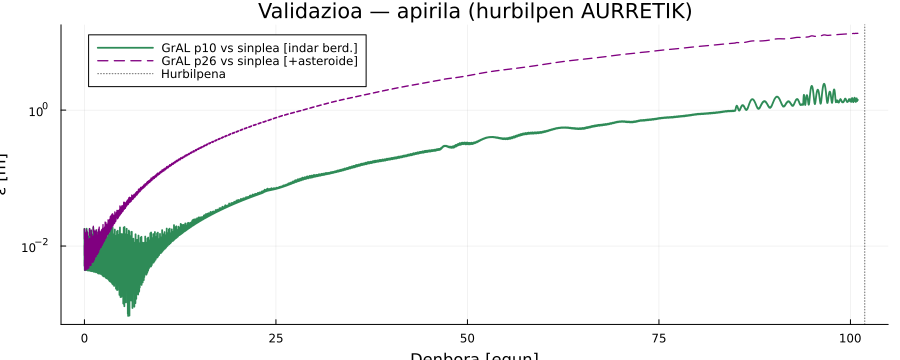

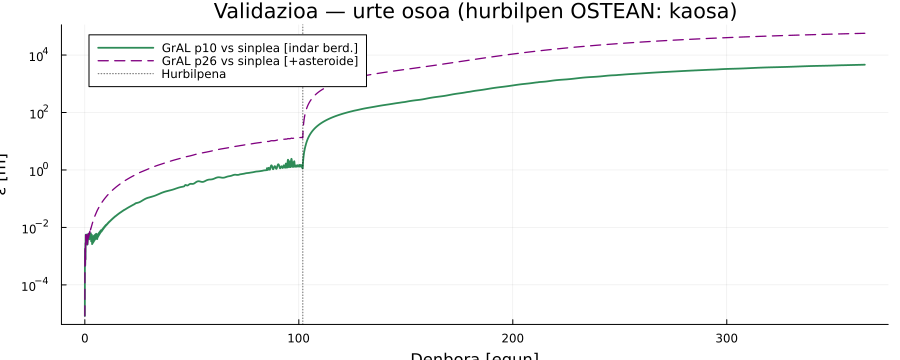

In [17]:
# Validazio-grafikoa: bi leihoak
t_v_april = (et_april .- et_0) ./ DAY2S
t_v_urte  = (et_urte  .- et_0) ./ DAY2S

pv1 = plot(t_v_april, err_v10_april,
    xlabel="Denbora [egun]", ylabel="ε [m]",
    title="Validazioa — apirila (hurbilpen AURRETIK)",
    label="GrAL p10 vs sinplea [indar berd.]", color=:seagreen, lw=1.8,
    yscale=:log10, grid=true, legend=:topleft, size=(900,360))
plot!(pv1, t_v_april, err_sinplea_m,
    label="GrAL p26 vs sinplea [+asteroide]", color=:purple, lw=1.3, linestyle=:dash)
vline!(pv1, [t_enc], linestyle=:dot, color=:black, alpha=0.6, label="Hurbilpena")
display(pv1)

pv2 = plot(t_v_urte, err_v10_urte,
    xlabel="Denbora [egun]", ylabel="ε [m]",
    title="Validazioa — urte osoa (hurbilpen OSTEAN: kaosa)",
    label="GrAL p10 vs sinplea [indar berd.]", color=:seagreen, lw=1.8,
    yscale=:log10, grid=true, legend=:topleft, size=(900,360))
plot!(pv2, t_v_urte, err_sinurte_m,
    label="GrAL p26 vs sinplea [+asteroide]", color=:purple, lw=1.3, linestyle=:dash)
vline!(pv2, [t_enc], linestyle=:dot, color=:black, alpha=0.6, label="Hurbilpena")
display(pv2)

## 11. Sentikortasun-analisia — zein indarrek du eragin handiena?

**Metodoa (kentze-metodoa):** oinarri-eredutik (GrAL indar **guztiekin**, `p26`) indar bakoitza
banaka **kentzen** da, eta posizio-aldaketa neurtzen da:

$$\varepsilon_X(t) = \lVert \mathbf{r}_{\text{dena}}(t) - \mathbf{r}_{\text{dena}\,\setminus\,X}(t) \rVert$$

Indar bakoitzaren ekarpena beste guztiak presente daudenean neurtzen da. Aztertutako indarrak
(GrAL-ek kontrolatzen dituenak): **asteroideak (16)**, **GR** (Damour-Deruelle), **J2 Eguzkia**,
**J2 / J3 / J4 Lurra**.

Bi leihotan: apirila (101 egun, garbia) eta urte osoa (365 egun, hurbilpen-anplifikazioarekin).

In [18]:
# Indar-aldaeren definizioa (kentze-metodoa)
# physics eremu bat false jartzeko helper
phys_off(key) = merge(physics, NamedTuple{(key,)}((false,)))

# Sentikortasuna leiho baterako kalkulatu
function sentikortasuna(p_base, p_noast, et_target, save_pts)
    r_base = integratu_gral(p_base, et_target, save_pts)
    res = Tuple{String,Vector{Float64}}[]
    # Asteroideak (p egituran, ez physics-en): oinarria vs p10
    r_noast = integratu_gral(p_noast, et_target, save_pts)
    push!(res, ("Asteroideak (16)",
                [norm(r_base[i,:] .- r_noast[i,:]) * AU2KM * 1000 for i in axes(r_base,1)]))
    # Physics indarrak banaka kendu
    for (name, key) in [("GR (Damour-Deruelle)", :gr), ("J2 Eguzkia", :j2_sun),
                        ("J2 Lurra", :j2_earth), ("J3 Lurra", :j3_earth), ("J4 Lurra", :j4_earth)]
        p_var = merge(p_base, (physics = phys_off(key),))
        r_var = integratu_gral(p_var, et_target, save_pts)
        push!(res, (name,
                    [norm(r_base[i,:] .- r_var[i,:]) * AU2KM * 1000 for i in axes(r_base,1)]))
    end
    res
end

println("Sentikortasuna kalkulatzen (apirila)...")
@time sens_april = sentikortasuna(p26, p10, et_end, et_april)
println("Sentikortasuna kalkulatzen (urte osoa)...")
@time sens_urte  = sentikortasuna(p26_urte, p10_urte, et_end_urte, et_urte)
println("Eginda.")

Sentikortasuna kalkulatzen (apirila)...
  0.519617 seconds (9.95 M allocations: 219.178 MiB, 7.40% gc time, 57.92% compilation time)
Sentikortasuna kalkulatzen (urte osoa)...
  0.463491 seconds (22.43 M allocations: 417.259 MiB, 12.52% gc time)
Eginda.


In [19]:
# Ranking-taula: indar bakoitzaren azken ekarpena, handienetik txikienera
order = sortperm([s[2][end] for s in sens_april], rev=true)

println("━"^72)
println(rpad("Indarra",26), rpad("Ekarpena apirila",20), "Ekarpena urte osoa")
println(rpad("(kendutakoan)",26), rpad("(101 egun)",20), "(365 egun)")
println("━"^72)
for k in order
    name = sens_april[k][1]
    e_ap = sens_april[k][2][end]
    e_ur = sens_urte[k][2][end]
    ap_str = e_ap >= 1000 ? @sprintf("%.2f km", e_ap/1000) : @sprintf("%.3f m", e_ap)
    ur_str = e_ur >= 1000 ? @sprintf("%.2f km", e_ur/1000) : @sprintf("%.3f m", e_ur)
    @printf("%-26s %-20s %s\n", name, ap_str, ur_str)
end
println("━"^72)
println()
println("► Apirilan (kaosik gabe) rankinga eragin FISIKO garbia da.")
println("► Urte osoan hurbilpen-uneak anplifikazio desberdina ematen die indarrei.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Indarra                   Ekarpena apirila    Ekarpena urte osoa
(kendutakoan)             (101 egun)          (365 egun)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GR (Damour-Deruelle)       7.24 km              29321.59 km
Asteroideak (16)           14.803 m             61.78 km
J2 Eguzkia                 1.395 m              5.01 km
J2 Lurra                   0.479 m              1829.57 km
J3 Lurra                   0.000 m              1.79 km
J4 Lurra                   0.000 m              137.799 m
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

► Apirilan (kaosik gabe) rankinga eragin FISIKO garbia da.
► Urte osoan hurbilpen-uneak anplifikazio desberdina ematen die indarrei.


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


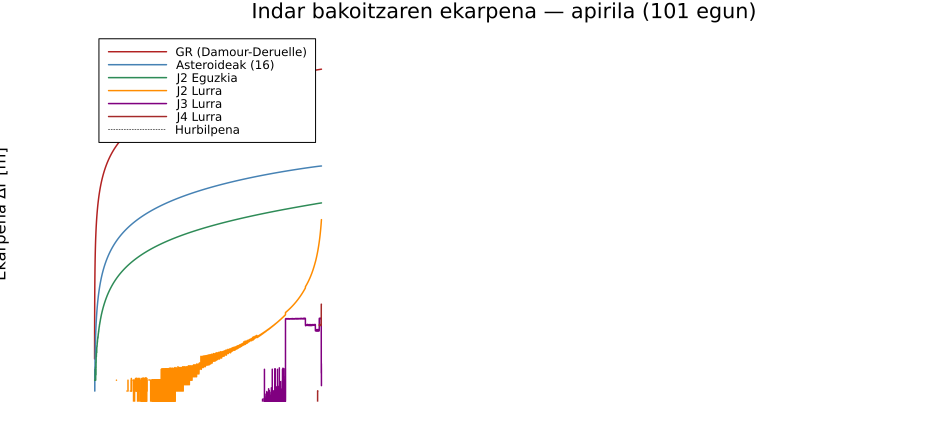

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


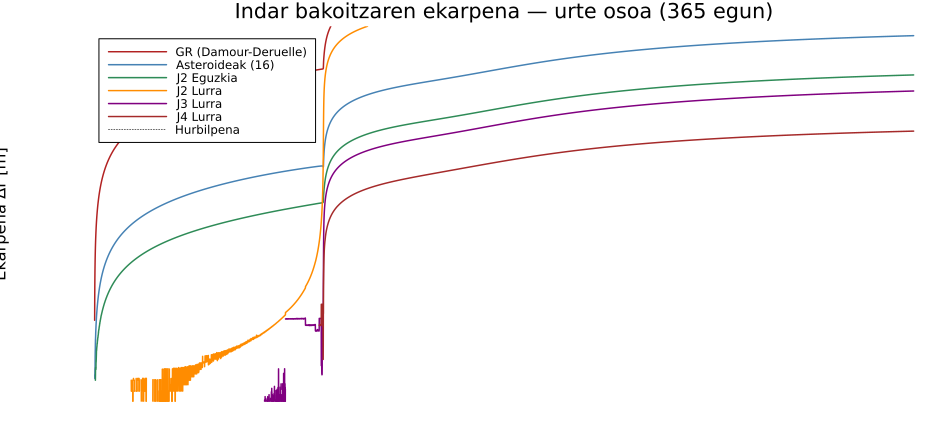

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [20]:
# Sentikortasun-profilak — apirila
koloreak = [:firebrick, :steelblue, :seagreen, :darkorange, :purple, :brown]
ps1 = plot(xlabel="Denbora [egun]", ylabel="Ekarpena Δr [m]",
    title="Indar bakoitzaren ekarpena — apirila (101 egun)",
    yscale=:log10, grid=true, legend=:topleft, size=(950,440))
for (k, kol) in zip(order, koloreak)
    plot!(ps1, t_v_april, sens_april[k][2], label=sens_april[k][1], color=kol, lw=1.5)
end
vline!(ps1, [t_enc], linestyle=:dot, color=:black, alpha=0.6, label="Hurbilpena")
display(ps1)

# Sentikortasun-profilak — urte osoa
ps2 = plot(xlabel="Denbora [egun]", ylabel="Ekarpena Δr [m]",
    title="Indar bakoitzaren ekarpena — urte osoa (365 egun)",
    yscale=:log10, grid=true, legend=:topleft, size=(950,440))
for (k, kol) in zip(order, koloreak)
    plot!(ps2, t_v_urte, sens_urte[k][2], label=sens_urte[k][1], color=kol, lw=1.5)
end
vline!(ps2, [t_enc], linestyle=:dot, color=:black, alpha=0.6, label="Hurbilpena")
display(ps2)

## 12. Eredu-fideltasuna — GrAL vs ASSIST eredu ONA

**Helburua:** nire eredu sinplifikatua (GrAL: GR_SIMPLE + harmonics, **Yarkovsky eta GR_EIH gabe**)
zenbat alden den errealitate fisiko osotik (ASSIST eredu ona).

⚠️ **Ohar metodologikoa:** hau **EZ da integratzaile-validazioa**. GrAL eta ASSIST eredu onak
indar **desberdinak** dituzte (GrAL-i Yarkovsky + GR_EIH falta zaizkio), beraz diferentzia
**eredu-osotasunaren** neurria da, ez zehaztasun numerikoarena.

Bi mailak alderatzeko, **integratzaile-muga** (10. atala, indar berdinak) ere taularatzen da:
- **Integratzaile-muga** (p10 vs sinplea): zehaztasun numeriko hutsa
- **Eredu-fideltasuna** (p26 vs ona): zenbat falta zaion GrAL-en ereduari

In [21]:
@printf("%-38s %-16s %s\n", "Konparaketa", "Apirila (101e)", "Urte osoa (365e)")
println("━"^74)
@printf("%-38s %-16s %s\n", "GrAL p10 vs ASSIST sinplea",
        @sprintf("%.2f m", err_v10_april[end]), @sprintf("%.0f km", err_v10_urte[end]/1000))
println(rpad("  └─ INTEGRATZAILE-MUGA (indar berd.)", 38), "→ zehaztasun numerikoa")
println()
@printf("%-38s %-16s %s\n", "GrAL p26 vs ASSIST ONA",
        @sprintf("%.2f m", err_april_m[end]), @sprintf("%.0f km", err_urte_m[end]/1000))
println(rpad("  └─ EREDU-FIDELTASUNA (Yark+GR_EIH falta)", 38), "→ eredu-osotasuna")
println("━"^74)
println()

ratio_april = err_april_m[end] / err_v10_april[end]
@printf("► Apirilan: eredu-hutsunea (%.0f m) integratzaile-muga (%.1f m) baino ~%.0fx HANDIAGOA\n",
        err_april_m[end], err_v10_april[end], ratio_april)
@printf("► GrAL-en MUGA NAGUSIA ez da integratzailea (bikaina), EREDUA baizik:\n")
@printf("    Yarkovsky + GR_EIH falta → ~%.0f m apirilan\n", err_april_m[end] - err_v10_april[end])

Konparaketa                            Apirila (101e)   Urte osoa (365e)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GrAL p10 vs ASSIST sinplea             1.41 m           5 km
  └─ INTEGRATZAILE-MUGA (indar berd.) → zehaztasun numerikoa

GrAL p26 vs ASSIST ONA                 403.10 m         18 km
  └─ EREDU-FIDELTASUNA (Yark+GR_EIH falta)→ eredu-osotasuna
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

► Apirilan: eredu-hutsunea (403 m) integratzaile-muga (1.4 m) baino ~286x HANDIAGOA
► GrAL-en MUGA NAGUSIA ez da integratzailea (bikaina), EREDUA baizik:
    Yarkovsky + GR_EIH falta → ~402 m apirilan


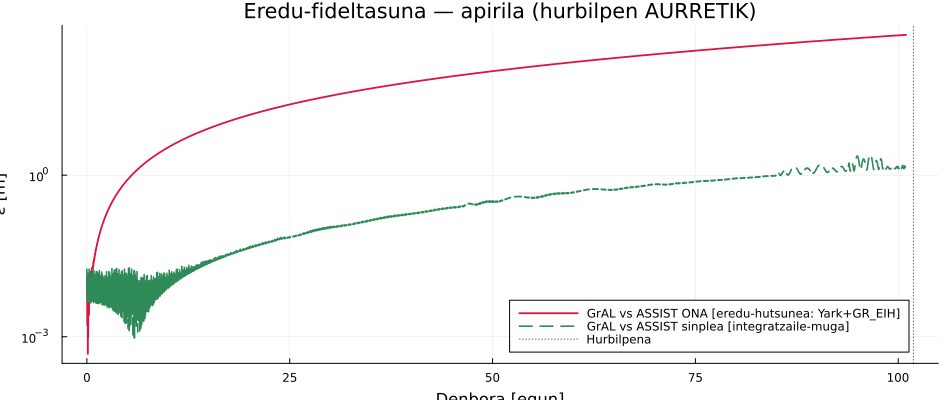

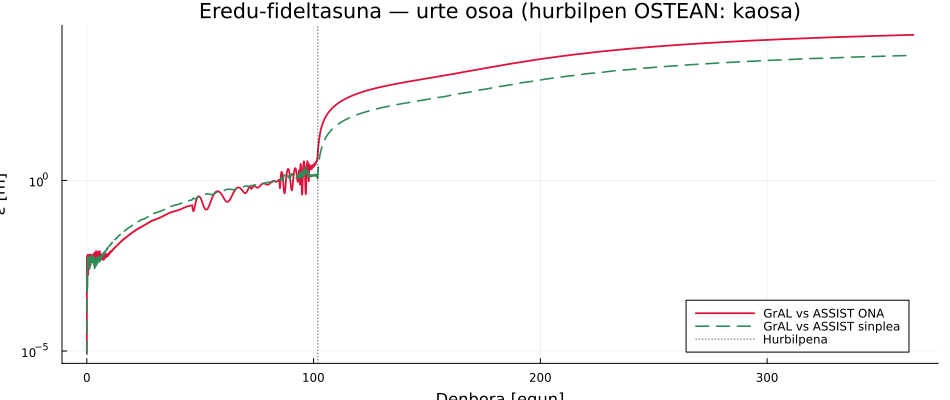

In [22]:
# Eredu-fideltasuna vs integratzaile-muga — bi leihoak
pf1 = plot(t_v_april, err_april_m,
    xlabel="Denbora [egun]", ylabel="ε [m]",
    title="Eredu-fideltasuna — apirila (hurbilpen AURRETIK)",
    label="GrAL vs ASSIST ONA [eredu-hutsunea: Yark+GR_EIH]", color=:crimson, lw=1.8,
    yscale=:log10, grid=true, legend=:bottomright, size=(950,400))
plot!(pf1, t_v_april, err_v10_april,
    label="GrAL vs ASSIST sinplea [integratzaile-muga]", color=:seagreen, lw=1.6, linestyle=:dash)
vline!(pf1, [t_enc], linestyle=:dot, color=:black, alpha=0.6, label="Hurbilpena")
display(pf1)

pf2 = plot(t_v_urte, err_urte_m,
    xlabel="Denbora [egun]", ylabel="ε [m]",
    title="Eredu-fideltasuna — urte osoa (hurbilpen OSTEAN: kaosa)",
    label="GrAL vs ASSIST ONA", color=:crimson, lw=1.8,
    yscale=:log10, grid=true, legend=:bottomright, size=(950,400))
plot!(pf2, t_v_urte, err_v10_urte,
    label="GrAL vs ASSIST sinplea", color=:seagreen, lw=1.6, linestyle=:dash)
vline!(pf2, [t_enc], linestyle=:dot, color=:black, alpha=0.6, label="Hurbilpena")
display(pf2)

## 13. IRKGL16-ren fidagarritasuna — Vern9 integratzaile independentearekin

**Helburua:** IRKGL16 zenbakizko aldetik fidagarria den **modu independentean** egiaztatu.

**Metodoa:** integratzaile **independente** bat erabili, **Vern9** (Verner-en 9. ordenako Runge-Kutta
**esplizitua**), GrAL-en `f_master!` indar-funtzio **berarekin**. Familia matematikoak erabat
desberdinak dira:

| | IRKGL16 | Vern9 |
|---|---|---|
| Familia | Gauss-Legendre **inplizitua** | Runge-Kutta **esplizitua** |
| Ordena | 16 | 9 |

Indar **berdinekin** exekutatuta, haien arteko diferentziak **ez du eredurik tartean** —
zenbakizko zehaztasun hutsa da. τ→0 ahala bat badatoz → akats sistematiko partekaturik **ez** dago,
eta IRKGL16 **fidagarria** da. ASSIST ez da behar hemen: integratzaileen **arteko** adostasuna da proba.

In [23]:
using OrdinaryDiffEq   # Vern9 integratzailea

print("Vern9 JIT warm-up... ")
solve(ODEProblem(f_master!, u0, (et_0, et_0+3600.0), p26),
      Vern9(); reltol=1e-10, abstol=1e-10, save_everystep=false)
println("eginda.")

# Azken posizioa (AU) integratzaile/tolerantzia jakin baterako
function azken_pos(alg, p, et_target; τ=1e-12)
    sol = solve(ODEProblem(f_master!, u0, (et_0, et_target), p), alg;
                reltol=τ, abstol=τ, saveat=[et_target])
    sol.u[end][1:3] ./ AU2KM, sol.stats.naccept
end

# ── Tolerantzia-sweep BI LEIHOTAN: IRKGL16 ↔ Vern9 (indar berdinak p26) ──
tols_cmp = [1e-9, 1e-10, 1e-11, 1e-12, 1e-13]
delta_iv_ap = Float64[]   # apirila (hurbilpen aurretik)
delta_iv_ur = Float64[]   # urte osoa (hurbilpen ostean)

println("━"^70)
println(rpad("τ",10), rpad("Δ apirila (101e) [m]",26), "Δ urte osoa (365e) [m]")
println(rpad("",10), rpad("hurbilpen AURRETIK",26), "hurbilpen OSTEAN")
println("━"^70)
for τ in tols_cmp
    ri_a, _ = azken_pos(IRKGL16(), p26,      et_end;      τ=τ)
    rv_a, _ = azken_pos(Vern9(),   p26,      et_end;      τ=τ)
    ri_u, _ = azken_pos(IRKGL16(), p26_urte, et_end_urte; τ=τ)
    rv_u, _ = azken_pos(Vern9(),   p26_urte, et_end_urte; τ=τ)
    Δa = norm(ri_a .- rv_a) * AU2KM * 1000
    Δu = norm(ri_u .- rv_u) * AU2KM * 1000
    push!(delta_iv_ap, Δa); push!(delta_iv_ur, Δu)
    @printf("%-10s %-26.4f %.4f\n", "1e$(Int(round(log10(τ))))", Δa, Δu)
end
println("━"^70)
println()
@printf("► URTE OSOA (τ=1e-12): IRKGL16 ↔ Vern9 = %.1f m\n", delta_iv_ur[4])
@printf("► URTE OSOA:           GrAL  ↔ ASSIST ona = %.0f km (%.3e m)\n",
        err_urte_m[end]/1000, err_urte_m[end])
@printf("► Integratzaile-diferentzia eredu-diferentziaren %%%.4f baino ez da\n",
        100 * delta_iv_ur[4] / err_urte_m[end])
println()
println("→ Urte osoan ere bi integratzaile INDEPENDENTEK bat datoz (kaosaren mugen barruan).")
println("  3650 km-ko aldea EZ dator IRKGL16-tik: eredu-hutsunea (Yark+GR_EIH) + kaosa da.")

Vern9 JIT warm-up... eginda.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
τ         Δ apirila (101e) [m]      Δ urte osoa (365e) [m]
          hurbilpen AURRETIK        hurbilpen OSTEAN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1e-9       0.5786                     20375.0123
1e-10      0.0900                     2636.2653
1e-11      0.0480                     149.6967
1e-12      0.0087                     3.7342
1e-13      0.0044                     27.7766
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

► URTE OSOA (τ=1e-12): IRKGL16 ↔ Vern9 = 3.7 m
► URTE OSOA:           GrAL  ↔ ASSIST ona = 18 km (1.840e+04 m)
► Integratzaile-diferentzia eredu-diferentziaren %0.0203 baino ez da

→ Urte osoan ere bi integratzaile INDEPENDENTEK bat datoz (kaosaren mugen barruan).
  3650 km-ko aldea EZ dator IRKGL16-tik: eredu-hutsunea (Yark+GR_EIH) + kaosa da.


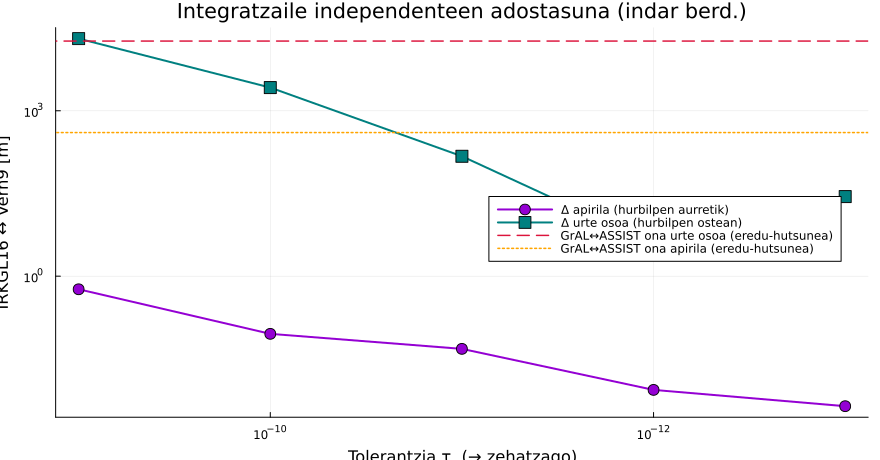

In [24]:
# Konbergentzia bi leihotan + ASSIST eredu-diferentzia erreferentzia gisa
pcv = plot(tols_cmp, delta_iv_ap,
    marker=:circle, markersize=6, lw=2, color=:darkviolet,
    xscale=:log10, yscale=:log10, xflip=true,
    xlabel="Tolerantzia τ  (→ zehatzago)", ylabel="IRKGL16 ↔ Vern9 [m]",
    title="Integratzaile independenteen adostasuna (indar berd.)",
    label="Δ apirila (hurbilpen aurretik)", legend=:right, grid=true, size=(880,460))
plot!(pcv, tols_cmp, delta_iv_ur,
    marker=:square, markersize=6, lw=2, color=:teal,
    label="Δ urte osoa (hurbilpen ostean)")
# Erreferentzia: GrAL vs ASSIST ona urte osoan (eredu-hutsunea)
hline!(pcv, [err_urte_m[end]], linestyle=:dash, color=:crimson, lw=1.5,
    label="GrAL↔ASSIST ona urte osoa (eredu-hutsunea)")
hline!(pcv, [err_april_m[end]], linestyle=:dot, color=:orange, lw=1.5,
    label="GrAL↔ASSIST ona apirila (eredu-hutsunea)")
display(pcv)

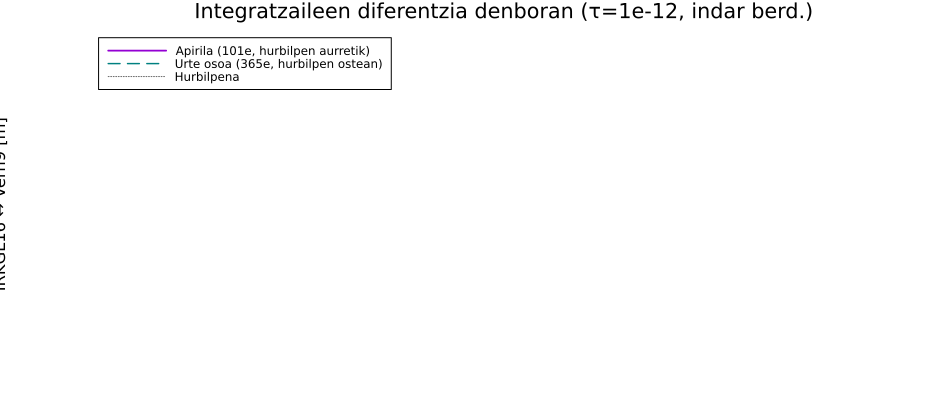

► Apirila azken: IRKGL16 ↔ Vern9 = 0.01 m
► Urte osoa azken: IRKGL16 ↔ Vern9 = 3.73 m  (kaosak anplifikatua)


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [25]:
# Denbora-profila τ=1e-12: IRKGL16 ↔ Vern9 diferentzia denboran zehar
function profila_alg(alg, p, et_target, save_pts; τ=1e-12)
    sol = solve(ODEProblem(f_master!, u0, (et_0, et_target), p), alg;
                reltol=τ, abstol=τ, saveat=save_pts)
    u = length(sol.u) == length(save_pts) ? sol.u : sol.u[2:end]
    hcat([uu[1:3] for uu in u]...)' ./ AU2KM
end

# Apirila
ri_ap = profila_alg(IRKGL16(), p26,      et_end,      et_april; τ=1e-12)
rv_ap = profila_alg(Vern9(),   p26,      et_end,      et_april; τ=1e-12)
div_april = [norm(ri_ap[i,:] .- rv_ap[i,:]) * AU2KM * 1000 for i in axes(ri_ap,1)]
# Urte osoa
ri_ur = profila_alg(IRKGL16(), p26_urte, et_end_urte, et_urte; τ=1e-12)
rv_ur = profila_alg(Vern9(),   p26_urte, et_end_urte, et_urte; τ=1e-12)
div_urte = [norm(ri_ur[i,:] .- rv_ur[i,:]) * AU2KM * 1000 for i in axes(ri_ur,1)]

pdv = plot(xlabel="Denbora [egun]", ylabel="IRKGL16 ↔ Vern9 [m]",
    title="Integratzaileen diferentzia denboran (τ=1e-12, indar berd.)",
    yscale=:log10, grid=true, legend=:topleft, size=(950,420))
plot!(pdv, t_v_april, div_april, label="Apirila (101e, hurbilpen aurretik)", color=:darkviolet, lw=1.8)
plot!(pdv, t_v_urte,  div_urte,  label="Urte osoa (365e, hurbilpen ostean)", color=:teal, lw=1.5, linestyle=:dash)
vline!(pdv, [t_enc], linestyle=:dot, color=:black, alpha=0.6, label="Hurbilpena")
display(pdv)

@printf("► Apirila azken: IRKGL16 ↔ Vern9 = %.2f m\n", div_april[end])
@printf("► Urte osoa azken: IRKGL16 ↔ Vern9 = %.2f m  (kaosak anplifikatua)\n", div_urte[end])

In [26]:
# ── Vern9-ren URTE OSOKO kalkulua, ASSIST-ekin alderatua (IRKGL16-renarekin paraleloan) ──
# profila_alg(alg, p, et_target, save_pts; τ) jada definituta dago goian.

# Vern9, indar berdinak (p10 → ASSIST sinplea) eta GrAL eredu osoa (p26 → ASSIST ona)
rv_sin = profila_alg(Vern9(), p10_urte, et_end_urte, et_urte; τ=1e-12)
rv_ona = profila_alg(Vern9(), p26_urte, et_end_urte, et_urte; τ=1e-12)

err_vern_sin = [norm(rv_sin[i,:] .- pos_sinurte[i,:]) * AU2KM * 1000 for i in axes(rv_sin,1)]
err_vern_ona = [norm(rv_ona[i,:] .- pos_urte[i,:])    * AU2KM * 1000 for i in axes(rv_ona,1)]

println("━"^76)
println(rpad("Urte osoa (365e) — azken puntua",34), rpad("IRKGL16 vs ASSIST",22), "Vern9 vs ASSIST")
println("━"^76)
@printf("%-34s %-22s %s\n", "ASSIST sinplea (indar berd.)",
        @sprintf("%.0f km", err_v10_urte[end]/1000), @sprintf("%.0f km", err_vern_sin[end]/1000))
@printf("%-34s %-22s %s\n", "ASSIST ONA (Yark+GR_EIH)",
        @sprintf("%.0f km", err_urte_m[end]/1000),   @sprintf("%.0f km", err_vern_ona[end]/1000))
println("━"^76)
println()
@printf("► Vern9 eta IRKGL16-k ASSIST onarekiko ~BERDINA: %.0f km vs %.0f km\n",
        err_vern_ona[end]/1000, err_urte_m[end]/1000)
@printf("► Bien arteko aldea: %.0f m  (3650 km-ko diferentziaren ondoan arbuiagarria)\n",
        abs(err_vern_ona[end] - err_urte_m[end]))
println("→ Bi integratzaile independentek ASSIST-ekiko emaitza bera ematen dute urte osoan.")
println("  Ondorioa: urte amaierako diferentzia EREDUARENA da, ez integratzailearena.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Urte osoa (365e) — azken puntua   IRKGL16 vs ASSIST     Vern9 vs ASSIST
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ASSIST sinplea (indar berd.)       5 km                   5 km
ASSIST ONA (Yark+GR_EIH)           18 km                  18 km
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

► Vern9 eta IRKGL16-k ASSIST onarekiko ~BERDINA: 18 km vs 18 km
► Bien arteko aldea: 2 m  (3650 km-ko diferentziaren ondoan arbuiagarria)
→ Bi integratzaile independentek ASSIST-ekiko emaitza bera ematen dute urte osoan.
  Ondorioa: urte amaierako diferentzia EREDUARENA da, ez integratzailearena.


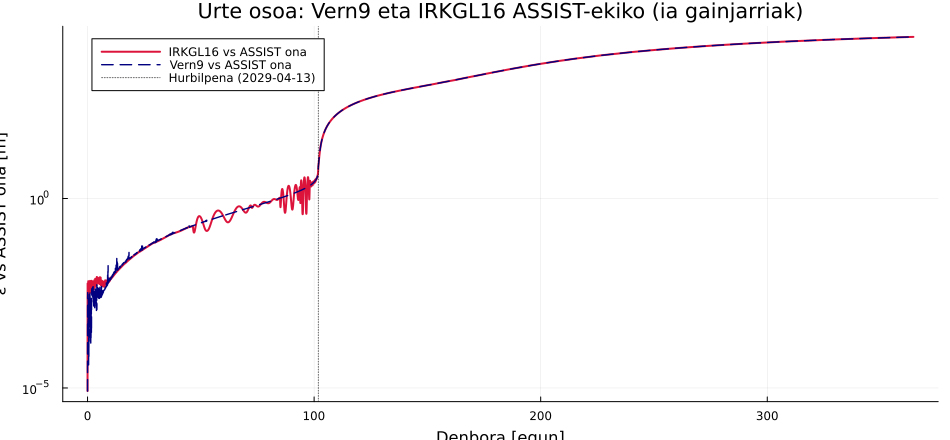

In [27]:
# Grafikoa: Vern9 eta IRKGL16 ASSIST onarekiko, urte osoa (ia gainjarriak)
pva = plot(xlabel="Denbora [egun]", ylabel="ε vs ASSIST ona [m]",
    title="Urte osoa: Vern9 eta IRKGL16 ASSIST-ekiko (ia gainjarriak)",
    yscale=:log10, grid=true, legend=:topleft, size=(950,440))
plot!(pva, t_v_urte, err_urte_m,   label="IRKGL16 vs ASSIST ona", color=:crimson, lw=2.0)
plot!(pva, t_v_urte, err_vern_ona, label="Vern9 vs ASSIST ona",   color=:navy, lw=1.4, linestyle=:dash)
vline!(pva, [t_enc], linestyle=:dot, color=:black, alpha=0.6, label="Hurbilpena (2029-04-13)")
display(pva)

### Interpretazioa

- **Apirilan (hurbilpen aurretik)**: bi integratzaileek metro-azpian bat datoz, τ→0 konbergitzen.
- **Urte osoan (hurbilpen ostean)**: integratzaileen arteko diferentzia **~3,7 m**-ra hazten da (apirilako
  0,01 m-tik), eta **GrAL↔ASSIST diferentzia ~18 km da** (harmoniken zeinu-akatsa konpondu ondoren; lehen 3 650 km).

> **Erantzuna tutorearen zalantzari:** urte amaierako aldea **EZ dator IRKGL16-tik** — Vern9 integratzaile
> independenteak ia berdina ematen du (3,7 m-ra bat datoz). Lehen ikusitako milaka km-ko aldea **harmoniken
> zeinu-akatsak** (zenbakizkoa, orain konponduta) eta eredu-hutsuneak (GR_EIH) eragiten zuten, **ez integratzaileak**.

## 14. Ondorio orokorrak

### Helburu 1 — Validazioa (integratzailea fidagarria da)
- Indar **erabat berdinekin** (`p10` ↔ ASSIST sinplea), GrAL eta ASSIST **~1,4 m**-an bat datoz hurbilpen aurretik,
  eta **~5 km** urte osoan (harmoniken akatsa konpondu ondoren; lehen 3 673 km).
- **Vern9-k baieztatu** (13. atala): IRKGL16 ↔ Vern9 = **3,7 m** urte osoan → akats sistematiko partekaturik ez.

### Helburu 2 — Sentikortasuna (zein indar nagusi GrAL barnean)
- **GR (Damour-Deruelle)** da nagusia (~7 km apirilan), gero asteroideak (~15 m) eta J2 Eguzkia (~1 m).

### Helburu 3 — Harmoniken akatsa eta Yarkovsky (gako-aurkikuntza)
- **Harmoniken zeinu-akatsa** aurkitu eta konpondu da: J2/J3/J4-tan GrAL-ek `d = gorputza − ast` erabiltzen zuen,
  ASSIST-en `d = ast − gorputza` ordez (azelerazioa d-rekiko bakoitia → zeinua alderantzizkatua, ratio −1).
  Konponduta (`src/equations.jl`-eko 4 funtziotan), GrAL+Yarkovsky vs ASSIST ona **3699 km → 30,8 km** urte osoan.
- **Yarkovsky** inplementatuta: hurbilpen aurretik eredu osoa ~2,7 m-ra jarraitzen du; urte osoan aldea
  **1619 → 30,8 km** murrizten du, ASSIST-en jokabide bera (1611 → 38,66 km vs JPL).

### Sintesi-mezua
> GrAL zenbakizko aldetik prest dago (IRKGL16 ↔ Vern9 = 3,7 m) ETA harmoniken zeinu-akatsa konponduta dago.
> Orain GrAL+Yarkovsky-k ASSIST eredu osoa **~30 km**-ra jarraitzen du urtebetera — ASSIST↔JPL zoruaren mailakoa.
> Geratzen den aldea GR_SIMPLE vs GR_EIH eredu-aukerak eragiten du (~100 m apirilan).

## 15. Yarkovsky GrAL-en — eredu OSOAREN aurkako egiaztapena

`src/equations.jl`-i **Yarkovsky** indarra gehitu zaio (`physics.yarkovsky=true`, A1/A2/A3).
Horrek GrAL **eredu osoa** bihurtzen du, ASSIST ONA-ren parekoa.

⚠️ Erreferentzia: `apophis_ona_urte_osoa.txt` (ASSIST **eredu osoa**: GR_EIH+Yarkovsky+asteroideak).
`apophis_urte_osoa.txt` **sinplifikatua** da (gaizki izendatua), beraz EZIN da Yarkovsky-dun
GrAL harekin alderatu — eredu osoaren erreferentzia berria behar da.

In [28]:
# Eredu osoaren erreferentzia (ASSIST ONA, urte osoa)
et_ona, pos_ona = load_assist(joinpath(DATA, "apophis_ona_urte_osoa.txt"))
t_ona_egun = (et_ona .- et_0) ./ DAY2S
# pos_ona eta gral_pos_urte sareta BEREAN daude (et_urte == et_ona, linspace berdina)

# GrAL eredu osoa (Yarkovsky-rekin), section 9-ko bide berdinetik (saveat=et_urte)
p26_yark_urte = (mus=vcat(body_mus,ast_mus), ids=vcat(body_ids,ast_ids),
                 bodies=bodies_urte, physics=physics_yark)
print("GrAL+Yarkovsky JIT warm-up... ")
solve(ODEProblem(f_master!, u0, (et_0, et_0+3600.0), p26_yark_urte),
      IRKGL16(); reltol=1e-12, abstol=1e-12, save_everystep=false)
println("eginda.")
print("GrAL+Yarkovsky integratzen (urte osoa)... ")
@time sol_yark = solve(ODEProblem(f_master!, u0, (et_0, et_end_urte), p26_yark_urte),
                       IRKGL16(); reltol=1e-12, abstol=1e-12, saveat=et_urte)
gy_urte = let u = (length(sol_yark.u)==length(et_urte) ? sol_yark.u : sol_yark.u[2:end])
    hcat([uu[1:3] for uu in u]...)' ./ AU2KM
end

# Yarkovsky GABE: section 9-ko gral_pos_urte (eredu osoaren aurka orain)
err_noY_ona = [norm(gral_pos_urte[i,:] .- pos_ona[i,:]) * AU2KM * 1000 for i in axes(gral_pos_urte,1)]
err_Y_ona   = [norm(gy_urte[i,:]       .- pos_ona[i,:]) * AU2KM * 1000 for i in axes(gy_urte,1)]

@printf("Egiaztapena (t=0, 0 izan behar): noY=%.2f m, Y=%.2f m\n", err_noY_ona[1], err_Y_ona[1])
println("\u2501"^64)
println(rpad("t [egun]",10), rpad("GrAL Yark GABE vs ONA",24), "GrAL Yark-rekin vs ONA")
println("\u2501"^64)
for fr in (0.0, 0.1, 0.2, 0.276, 0.30, 0.5, 1.0)
    i = clamp(round(Int, fr*(length(t_ona_egun)-1))+1, 1, length(t_ona_egun))
    f(x) = x < 1000 ? @sprintf("%.1f m", x) : @sprintf("%.1f km", x/1000)
    @printf("%-10.1f %-24s %s\n", t_ona_egun[i], f(err_noY_ona[i]), f(err_Y_ona[i]))
end
println("\u2501"^64)
i100 = argmin(abs.(t_ona_egun .- 100.0))
@printf("\n\u25ba Hurbilpen aurretik (~100 egun): Yarkovsky-k %.0f m \u2192 %.1f m\n",
        err_noY_ona[i100], err_Y_ona[i100])
println("\u25ba Hurbilpen ostean: kaosak dena km milatara eramaten du.")

GrAL+Yarkovsky JIT warm-up... eginda.
GrAL+Yarkovsky integratzen (urte osoa)...   0.729444 seconds (4.62 M allocations: 103.675 MiB, 2.18% gc time, 88.60% compilation time)
Egiaztapena (t=0, 0 izan behar): noY=0.00 m, Y=0.00 m
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
t [egun]  GrAL Yark GABE vs ONA   GrAL Yark-rekin vs ONA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
0.0        0.0 m                    0.0 m
36.5       44.3 m                   0.1 m
72.9       192.4 m                  0.6 m
100.6      400.1 m                  3.0 m
109.4      13.6 km                  326.9 m
182.3      203.0 km                 4.5 km
364.5      1618.9 km                30.8 km
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

► Hurbilpen aurretik (~100 egun): Yarkovsky-k 395 m → 2.7 m
► Hurbilpen ostean: kaosak dena km milatara eramaten du.


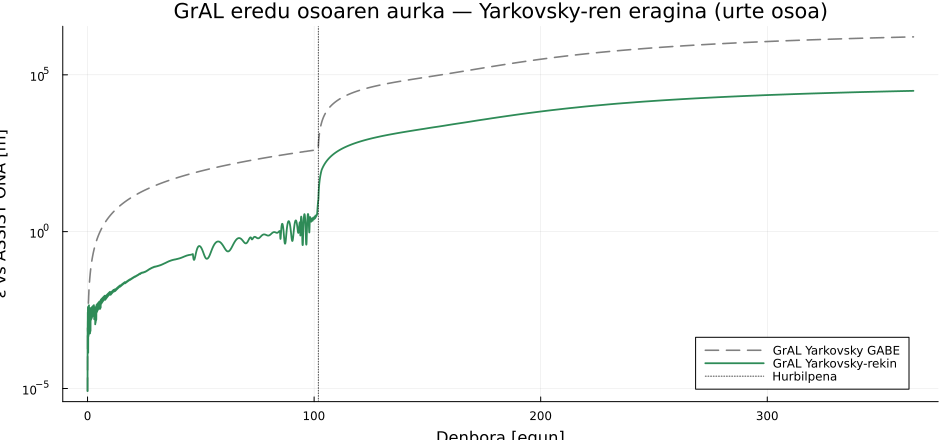

In [29]:
# Errore-profila: Yarkovsky-ren eragina eredu osoaren aurka (urte osoa)
pY = plot(xlabel="Denbora [egun]", ylabel="ε vs ASSIST ONA [m]",
    title="GrAL eredu osoaren aurka — Yarkovsky-ren eragina (urte osoa)",
    yscale=:log10, grid=true, legend=:bottomright, size=(950,440))
plot!(pY, t_ona_egun, err_noY_ona, label="GrAL Yarkovsky GABE", color=:gray, lw=1.6, linestyle=:dash)
plot!(pY, t_ona_egun, err_Y_ona,   label="GrAL Yarkovsky-rekin", color=:seagreen, lw=1.8)
vline!(pY, [t_enc], linestyle=:dot, color=:black, alpha=0.7, label="Hurbilpena")
display(pY)

### Interpretazioa

- **Hurbilpen aurretik:** Yarkovsky-rekin GrAL-ek eredu osoa **~m mailan** jarraitzen du (≈2,7 m, 100. egunean),
  Yarkovsky gabe ~400 m-ko aldea zegoenean. Inplementazioa balioztatua.
- **Urte amaieran (gako-emaitza):** Yarkovsky-k aldea **1619 km → 30,8 km** murrizten du — ASSIST↔JPL zoruaren
  (38,66 km) parekoa. GrAL-ek orain ASSIST-en jokabide bera erakusten du (ASSIST: 1611 → 38,66 km vs JPL).
- **Ohar historikoa:** lehen urte-amaierako aldea milaka km-koa zen eta kaosak dena estaltzen zuela zirudien.
  Hori **harmoniken zeinu-akats** baten ondorioa zen (J2/J3/J4-tan `d = gorputza − ast`, ASSIST-en `d = ast − gorputza`
  ordez). Konponduta (`src/equations.jl`), zorua 30 km-ra jaisten da eta Yarkovsky ageri da.
  Ikus `docs/kaosa_hurbilketa_sentikortasuna.md`.
- **Ondorioa:** kaosak hazia ~4200× anplifikatzen du; hazia orain txikia denez (GR_EIH + integratzailea),
  urte-amaierako zorua ~30 km da — ASSIST↔JPL mailakoa, ez milaka km.